# Chapter 22 Python Lab  
## Curl, Divergence, and Surface Integrals

This lab accompanies **Chapter 22: Curl, Divergence, and Surface Integrals**.

Vector calculus in three dimensions has two fundamental local measurements:

- **divergence**, which measures local expansion or compression;
- **curl**, which measures local rotation.

For a vector field

$$
\mathbf F(x,y,z)=\langle P(x,y,z),Q(x,y,z),R(x,y,z)\rangle,
$$

the divergence is

$$
\nabla\cdot\mathbf F=P_x+Q_y+R_z,
$$

and the curl is

$$
\nabla\times\mathbf F
=
\left\langle
R_y-Q_z,\;
P_z-R_x,\;
Q_x-P_y
\right\rangle.
$$

Surface integrals extend double integrals to curved surfaces.  
For a parametrized surface

$$
\mathbf r(u,v),
$$

the surface area element is

$$
dS=|\mathbf r_u\times\mathbf r_v|\,du\,dv.
$$

For a vector field, the flux through an oriented surface is

$$
\iint_S \mathbf F\cdot\mathbf n\,dS
=
\iint_D \mathbf F(\mathbf r(u,v))\cdot
(\mathbf r_u\times\mathbf r_v)\,du\,dv.
$$

This lab uses Python to explore:

- divergence and curl numerically and analytically;
- 3D vector field visualization through slices;
- parametrized surfaces;
- surface area integrals;
- flux through planes, graphs, cylinders, and spheres;
- orientation and sign;
- surface integrals over graph surfaces;
- the geometric meaning of $\mathbf r_u\times\mathbf r_v$;
- numerical checks of divergence theorem and Stokes-type circulation ideas;
- and a mini-project on flux through a curved sensor surface.

Only `numpy` and `matplotlib` are required.

## Learning goals

By the end of this lab, you should be able to:

1. compute divergence and curl for vector fields in $\mathbb R^3$;
2. interpret divergence as local source strength;
3. interpret curl as local rotation axis and rotational strength;
4. plot vector fields and scalar/vector diagnostic quantities;
5. parametrize planes, graphs, cylinders, and spheres;
6. compute surface area elements from cross products;
7. approximate scalar surface integrals $\iint_S f\,dS$;
8. approximate flux integrals $\iint_S \mathbf F\cdot\mathbf n\,dS$;
9. understand how orientation changes flux sign;
10. compare surface flux with volume divergence in examples.

## Source note

This notebook was generated from the uploaded Chapter 22 QMD file.  
The extracted early headings from the source file include:

- Learning goals
- The main theme
- The differential operator $\nabla$
- Curl
- Curl in the plane
- Example: a rotating field
- Example: curl of a three-dimensional field
- Divergence
- Divergence is a scalar field
- Example: a source field
- Example: an incompressible rotational field
- Two fundamental identities
- Smoothness and domain matter
- Numerical curl and divergence on a grid

## 0. Setup

Run this cell first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.set_printoptions(precision=6, suppress=True)
norm = np.linalg.norm

def safe_eval_3d(f, X, Y, Z):
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        W = f(X, Y, Z)
    return np.asarray(W, dtype=float)

def safe_eval_2d(f, X, Y):
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        W = f(X, Y)
    return np.asarray(W, dtype=float)

def make_grid2d(xmin=-3, xmax=3, ymin=-3, ymax=3, n=250):
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    X, Y = np.meshgrid(x, y)
    return x, y, X, Y

def make_grid3d(xmin=-2, xmax=2, ymin=-2, ymax=2, zmin=-2, zmax=2, n=9):
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    z = np.linspace(zmin, zmax, n)
    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
    return x, y, z, X, Y, Z

def make_3d_axes(title=None, elev=25, azim=45):
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    if title:
        ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)
    return fig, ax

def plot_vector_field_3d(F, xmin=-2, xmax=2, ymin=-2, ymax=2, zmin=-2, zmax=2,
                         n=7, normalize=True, title="3D vector field"):
    x, y, z, X, Y, Z = make_grid3d(xmin, xmax, ymin, ymax, zmin, zmax, n=n)
    U, V, W = F(X, Y, Z)
    M = np.sqrt(U**2 + V**2 + W**2)
    if normalize:
        Uplot = U/(M+1e-12)
        Vplot = V/(M+1e-12)
        Wplot = W/(M+1e-12)
    else:
        Uplot, Vplot, Wplot = U, V, W
    fig, ax = make_3d_axes(title=title, elev=22, azim=45)
    ax.quiver(X, Y, Z, Uplot, Vplot, Wplot, length=0.28, normalize=False)
    plt.show()
    return X, Y, Z, U, V, W, M

def plot_vector_field_slice_xy(F, z0=0, xmin=-3, xmax=3, ymin=-3, ymax=3,
                               n=23, normalize=True, title="Vector field slice"):
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    X, Y = np.meshgrid(x, y)
    Z = z0*np.ones_like(X)
    U, V, W = F(X, Y, Z)
    Mxy = np.sqrt(U**2 + V**2)
    if normalize:
        Uplot = U/(Mxy+1e-12)
        Vplot = V/(Mxy+1e-12)
    else:
        Uplot, Vplot = U, V
    plt.figure(figsize=(7, 6))
    plt.quiver(X, Y, Uplot, Vplot, Mxy)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title + f" at z={z0}")
    plt.axis("equal")
    plt.grid(True, alpha=0.25)
    plt.show()

def finite_partial_3d_component(g, X, Y, Z, var="x", h=1e-5):
    if var == "x":
        return (g(X+h, Y, Z) - g(X-h, Y, Z))/(2*h)
    if var == "y":
        return (g(X, Y+h, Z) - g(X, Y-h, Z))/(2*h)
    if var == "z":
        return (g(X, Y, Z+h) - g(X, Y, Z-h))/(2*h)
    raise ValueError("var must be 'x', 'y', or 'z'.")

def numerical_divergence_3d(F, X, Y, Z, h=1e-5):
    P = lambda x, y, z: F(x, y, z)[0]
    Q = lambda x, y, z: F(x, y, z)[1]
    R = lambda x, y, z: F(x, y, z)[2]
    return (
        finite_partial_3d_component(P, X, Y, Z, "x", h=h)
        + finite_partial_3d_component(Q, X, Y, Z, "y", h=h)
        + finite_partial_3d_component(R, X, Y, Z, "z", h=h)
    )

def numerical_curl_3d(F, X, Y, Z, h=1e-5):
    P = lambda x, y, z: F(x, y, z)[0]
    Q = lambda x, y, z: F(x, y, z)[1]
    R = lambda x, y, z: F(x, y, z)[2]
    curl_x = finite_partial_3d_component(R, X, Y, Z, "y", h=h) - finite_partial_3d_component(Q, X, Y, Z, "z", h=h)
    curl_y = finite_partial_3d_component(P, X, Y, Z, "z", h=h) - finite_partial_3d_component(R, X, Y, Z, "x", h=h)
    curl_z = finite_partial_3d_component(Q, X, Y, Z, "x", h=h) - finite_partial_3d_component(P, X, Y, Z, "y", h=h)
    return curl_x, curl_y, curl_z

def midpoint_rectangle_2d(integrand, umin, umax, vmin, vmax, nu=250, nv=250):
    du = (umax - umin)/nu
    dv = (vmax - vmin)/nv
    u = umin + (np.arange(nu)+0.5)*du
    v = vmin + (np.arange(nv)+0.5)*dv
    U, V = np.meshgrid(u, v)
    W = safe_eval_2d(integrand, U, V)
    return float(np.sum(W)*du*dv), U, V, W

def param_surface_integral_scalar(param, ru, rv, f_scalar, umin, umax, vmin, vmax, nu=250, nv=250):
    def integrand(U, V):
        X, Y, Z = param(U, V)
        Ru = np.array(ru(U, V))
        Rv = np.array(rv(U, V))
        cross = np.cross(Ru.T, Rv.T).T
        dS = np.sqrt(np.sum(cross**2, axis=0))
        return safe_eval_3d(f_scalar, X, Y, Z)*dS
    return midpoint_rectangle_2d(integrand, umin, umax, vmin, vmax, nu=nu, nv=nv)

def param_surface_flux(F, param, ru, rv, umin, umax, vmin, vmax, nu=250, nv=250):
    def integrand(U, V):
        X, Y, Z = param(U, V)
        Ru = np.array(ru(U, V))
        Rv = np.array(rv(U, V))
        cross = np.cross(Ru.T, Rv.T).T
        P, Q, R = F(X, Y, Z)
        return P*cross[0] + Q*cross[1] + R*cross[2]
    return midpoint_rectangle_2d(integrand, umin, umax, vmin, vmax, nu=nu, nv=nv)

def graph_surface_area(gx, gy, xmin, xmax, ymin, ymax, nx=300, ny=300):
    def integrand(X, Y):
        return np.sqrt(1 + gx(X, Y)**2 + gy(X, Y)**2)
    return midpoint_rectangle_2d(integrand, xmin, xmax, ymin, ymax, nu=nx, nv=ny)

def graph_surface_flux_upward(F, g, gx, gy, xmin, xmax, ymin, ymax, nx=300, ny=300):
    def integrand(X, Y):
        Z = g(X, Y)
        P, Q, R = F(X, Y, Z)
        return P*(-gx(X, Y)) + Q*(-gy(X, Y)) + R
    return midpoint_rectangle_2d(integrand, xmin, xmax, ymin, ymax, nu=nx, nv=ny)

def plot_param_surface(param, umin, umax, vmin, vmax, nu=80, nv=80, title="Parametrized surface",
                       elev=25, azim=45, alpha=0.75):
    u = np.linspace(umin, umax, nu)
    v = np.linspace(vmin, vmax, nv)
    U, V = np.meshgrid(u, v)
    X, Y, Z = param(U, V)
    fig, ax = make_3d_axes(title=title, elev=elev, azim=azim)
    ax.plot_surface(X, Y, Z, linewidth=0, alpha=alpha)
    plt.show()
    return X, Y, Z

def plot_graph_surface(g, xmin, xmax, ymin, ymax, n=120, title="Graph surface", elev=28, azim=45):
    x, y, X, Y = make_grid2d(xmin, xmax, ymin, ymax, n=n)
    Z = g(X, Y)
    fig, ax = make_3d_axes(title=title, elev=elev, azim=azim)
    ax.plot_surface(X, Y, Z, linewidth=0, alpha=0.8)
    plt.show()
    return X, Y, Z

def volume_integral_box(g, xmin, xmax, ymin, ymax, zmin, zmax, nx=90, ny=90, nz=90):
    dx = (xmax-xmin)/nx
    dy = (ymax-ymin)/ny
    dz = (zmax-zmin)/nz
    x = xmin + (np.arange(nx)+0.5)*dx
    y = ymin + (np.arange(ny)+0.5)*dy
    z = zmin + (np.arange(nz)+0.5)*dz
    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
    W = safe_eval_3d(g, X, Y, Z)
    return float(np.sum(W)*dx*dy*dz)

def volume_integral_mask(g, xmin, xmax, ymin, ymax, zmin, zmax, mask, nx=90, ny=90, nz=90):
    dx = (xmax-xmin)/nx
    dy = (ymax-ymin)/ny
    dz = (zmax-zmin)/nz
    x = xmin + (np.arange(nx)+0.5)*dx
    y = ymin + (np.arange(ny)+0.5)*dy
    z = zmin + (np.arange(nz)+0.5)*dz
    X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
    inside = mask(X, Y, Z)
    W = safe_eval_3d(g, X, Y, Z)
    return float(np.sum(W[inside])*dx*dy*dz), X, Y, Z, inside, W

def one3(X, Y, Z):
    return np.ones_like(np.asarray(X, dtype=float))

print("Setup complete.")

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-1aqvcdei because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Setup complete.


---

# Part I. Divergence in three dimensions

For

$$
\mathbf F=\langle P,Q,R\rangle,
$$

the divergence is

$$
\nabla\cdot\mathbf F=P_x+Q_y+R_z.
$$

Divergence measures the local source strength of a vector field.

- Positive divergence: local expansion/source.
- Negative divergence: local compression/sink.
- Zero divergence: locally incompressible.

## 1. Radial source field

The field

$$
\mathbf F(x,y,z)=\langle x,y,z\rangle
$$

points outward from the origin.

Its divergence is

$$
\nabla\cdot\mathbf F=1+1+1=3.
$$

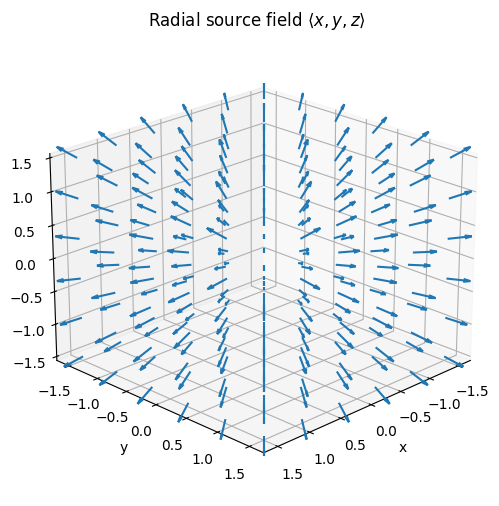

point (0.0, 0.0, 0.0): numerical divergence = 3.000000
point (1.0, 0.5, -0.3): numerical divergence = 3.000000
point (-1.2, 1.1, 2.0): numerical divergence = 3.000000


In [2]:
def F_radial3(X, Y, Z):
    return X, Y, Z

plot_vector_field_3d(
    F_radial3,
    xmin=-1.5, xmax=1.5,
    ymin=-1.5, ymax=1.5,
    zmin=-1.5, zmax=1.5,
    n=6,
    normalize=True,
    title=r"Radial source field $\langle x,y,z\rangle$"
)

probe_points = [
    (0.0, 0.0, 0.0),
    (1.0, 0.5, -0.3),
    (-1.2, 1.1, 2.0),
]

for p in probe_points:
    div = numerical_divergence_3d(F_radial3, *p)
    print(f"point {p}: numerical divergence = {div:.6f}")

## 2. Sink field

The field

$$
\mathbf F(x,y,z)=\langle -x,-y,-z\rangle
$$

has divergence

$$
-3.
$$

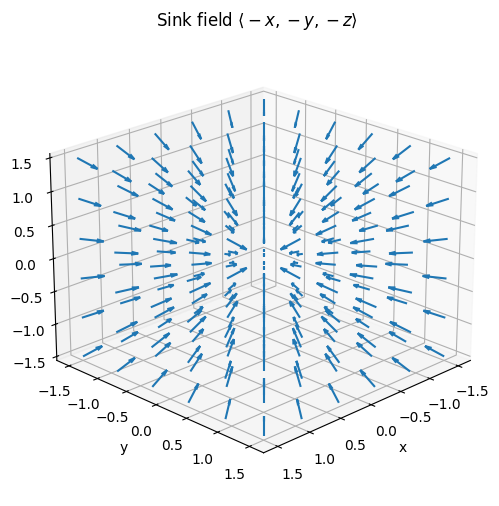

point (0.0, 0.0, 0.0): numerical divergence = -3.000000
point (1.0, 0.5, -0.3): numerical divergence = -3.000000
point (-1.2, 1.1, 2.0): numerical divergence = -3.000000


In [3]:
def F_sink3(X, Y, Z):
    return -X, -Y, -Z

plot_vector_field_3d(
    F_sink3,
    xmin=-1.5, xmax=1.5,
    ymin=-1.5, ymax=1.5,
    zmin=-1.5, zmax=1.5,
    n=6,
    normalize=True,
    title=r"Sink field $\langle -x,-y,-z\rangle$"
)

for p in probe_points:
    div = numerical_divergence_3d(F_sink3, *p)
    print(f"point {p}: numerical divergence = {div:.6f}")

## 3. Incompressible rotational field

The field

$$
\mathbf F(x,y,z)=\langle -y,x,0\rangle
$$

rotates around the $z$-axis.

Its divergence is

$$
0+0+0=0.
$$

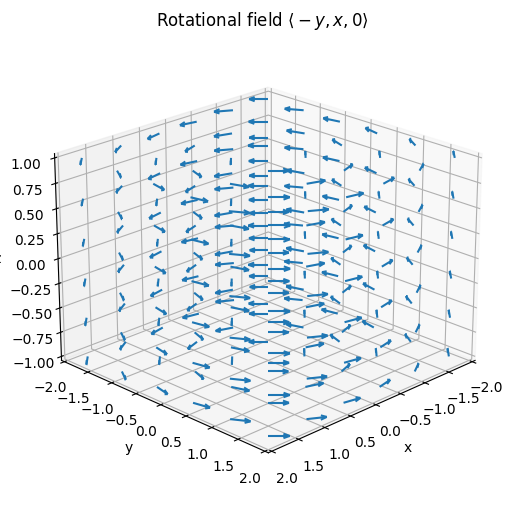

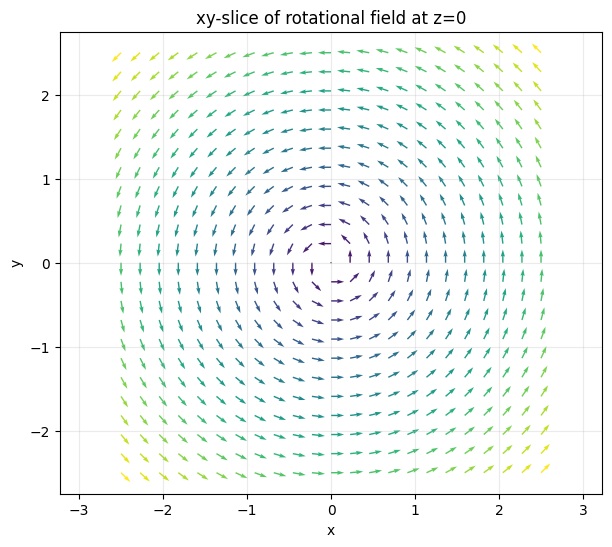

point (0.0, 0.0, 0.0): numerical divergence = 0.000000
point (1.0, 0.5, -0.3): numerical divergence = 0.000000
point (-1.2, 1.1, 2.0): numerical divergence = 0.000000


In [4]:
def F_rotation_z(X, Y, Z):
    return -Y, X, 0*Z

plot_vector_field_3d(
    F_rotation_z,
    xmin=-1.8, xmax=1.8,
    ymin=-1.8, ymax=1.8,
    zmin=-1.0, zmax=1.0,
    n=6,
    normalize=True,
    title=r"Rotational field $\langle -y,x,0\rangle$"
)

plot_vector_field_slice_xy(
    F_rotation_z,
    z0=0,
    xmin=-2.5, xmax=2.5,
    ymin=-2.5, ymax=2.5,
    n=23,
    normalize=True,
    title="xy-slice of rotational field"
)

for p in probe_points:
    div = numerical_divergence_3d(F_rotation_z, *p)
    print(f"point {p}: numerical divergence = {div:.6f}")

---

# Part II. Curl in three dimensions

For

$$
\mathbf F=\langle P,Q,R\rangle,
$$

the curl is

$$
\nabla\times\mathbf F
=
\left\langle
R_y-Q_z,\;
P_z-R_x,\;
Q_x-P_y
\right\rangle.
$$

Curl measures local rotation. Its direction is the local axis of rotation.

## 4. Curl of a rotation around the $z$-axis

For

$$
\mathbf F=\langle -y,x,0\rangle,
$$

we get

$$
\nabla\times\mathbf F
=
\langle 0,0,2\rangle.
$$

The local rotation axis points in the positive $z$-direction.

In [5]:
for p in probe_points:
    curl = numerical_curl_3d(F_rotation_z, *p)
    print(f"point {p}: numerical curl = {np.array(curl)}")

point (0.0, 0.0, 0.0): numerical curl = [0. 0. 2.]
point (1.0, 0.5, -0.3): numerical curl = [0. 0. 2.]
point (-1.2, 1.1, 2.0): numerical curl = [0. 0. 2.]


## 5. Curl-free gradient field

If

$$
\mathbf F=\nabla f
$$

for a smooth scalar potential, then

$$
\nabla\times\mathbf F=\mathbf 0.
$$

Let

$$
f(x,y,z)=x^2+y^2+z^2.
$$

Then

$$
\nabla f=\langle 2x,2y,2z\rangle.
$$

In [6]:
def F_grad_bowl3(X, Y, Z):
    return 2*X, 2*Y, 2*Z

for p in probe_points:
    curl = numerical_curl_3d(F_grad_bowl3, *p)
    div = numerical_divergence_3d(F_grad_bowl3, *p)
    print(f"point {p}: curl = {np.array(curl)}, divergence = {div:.6f}")

point (0.0, 0.0, 0.0): curl = [0. 0. 0.], divergence = 6.000000
point (1.0, 0.5, -0.3): curl = [0. 0. 0.], divergence = 6.000000
point (-1.2, 1.1, 2.0): curl = [0. 0. 0.], divergence = 6.000000


## 6. A field with nonconstant divergence and curl

Let

$$
\mathbf F(x,y,z)=\langle yz,\;xz,\;xy\rangle.
$$

This field has

$$
\nabla\cdot\mathbf F=0,
$$

and

$$
\nabla\times\mathbf F=\mathbf 0.
$$

In fact it is the gradient of the potential $f(x,y,z)=xyz$.

In [7]:
def F_xyz_grad(X, Y, Z):
    return Y*Z, X*Z, X*Y

for p in probe_points:
    curl = numerical_curl_3d(F_xyz_grad, *p)
    div = numerical_divergence_3d(F_xyz_grad, *p)
    print(f"point {p}: curl = {np.array(curl)}, divergence = {div:.6f}")

point (0.0, 0.0, 0.0): curl = [0. 0. 0.], divergence = 0.000000
point (1.0, 0.5, -0.3): curl = [-0.  0. -0.], divergence = 0.000000
point (-1.2, 1.1, 2.0): curl = [-0.  0.  0.], divergence = 0.000000


### Guided task 1

For

$$
\mathbf F(x,y,z)=\langle 0,-z,y\rangle,
$$

compute the divergence and curl numerically.  
This field rotates around the $x$-axis.

point (0.0, 0.0, 0.0): divergence=0.000000, curl=[2. 0. 0.]
point (1.0, 0.5, -0.3): divergence=0.000000, curl=[2. 0. 0.]
point (-1.2, 1.1, 2.0): divergence=0.000000, curl=[2. 0. 0.]


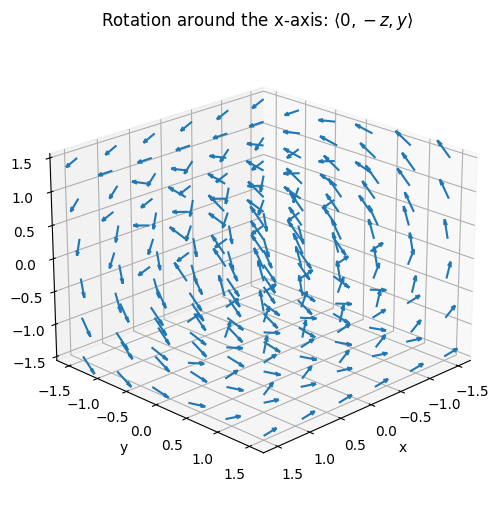

(array([[[-1.5, -1.5, -1.5, -1.5, -1.5, -1.5],
         [-1.5, -1.5, -1.5, -1.5, -1.5, -1.5],
         [-1.5, -1.5, -1.5, -1.5, -1.5, -1.5],
         [-1.5, -1.5, -1.5, -1.5, -1.5, -1.5],
         [-1.5, -1.5, -1.5, -1.5, -1.5, -1.5],
         [-1.5, -1.5, -1.5, -1.5, -1.5, -1.5]],
 
        [[-0.9, -0.9, -0.9, -0.9, -0.9, -0.9],
         [-0.9, -0.9, -0.9, -0.9, -0.9, -0.9],
         [-0.9, -0.9, -0.9, -0.9, -0.9, -0.9],
         [-0.9, -0.9, -0.9, -0.9, -0.9, -0.9],
         [-0.9, -0.9, -0.9, -0.9, -0.9, -0.9],
         [-0.9, -0.9, -0.9, -0.9, -0.9, -0.9]],
 
        [[-0.3, -0.3, -0.3, -0.3, -0.3, -0.3],
         [-0.3, -0.3, -0.3, -0.3, -0.3, -0.3],
         [-0.3, -0.3, -0.3, -0.3, -0.3, -0.3],
         [-0.3, -0.3, -0.3, -0.3, -0.3, -0.3],
         [-0.3, -0.3, -0.3, -0.3, -0.3, -0.3],
         [-0.3, -0.3, -0.3, -0.3, -0.3, -0.3]],
 
        [[ 0.3,  0.3,  0.3,  0.3,  0.3,  0.3],
         [ 0.3,  0.3,  0.3,  0.3,  0.3,  0.3],
         [ 0.3,  0.3,  0.3,  0.3,  0.3,  0.3],
    

In [8]:
def F_rotation_x(X, Y, Z):
    return 0*X, -Z, Y

for p in probe_points:
    curl = numerical_curl_3d(F_rotation_x, *p)
    div = numerical_divergence_3d(F_rotation_x, *p)
    print(f"point {p}: divergence={div:.6f}, curl={np.array(curl)}")

plot_vector_field_3d(
    F_rotation_x,
    xmin=-1.5, xmax=1.5,
    ymin=-1.5, ymax=1.5,
    zmin=-1.5, zmax=1.5,
    n=6,
    normalize=True,
    title=r"Rotation around the x-axis: $\langle 0,-z,y\rangle$"
)

---

# Part III. Surface parametrizations and area elements

A parametrized surface is a function

$$
\mathbf r(u,v)=\langle x(u,v),y(u,v),z(u,v)\rangle.
$$

The tangent vectors are

$$
\mathbf r_u,\qquad \mathbf r_v.
$$

The cross product

$$
\mathbf r_u\times\mathbf r_v
$$

is normal to the surface. Its length gives the area scaling factor:

$$
dS=|\mathbf r_u\times\mathbf r_v|\,du\,dv.
$$

## 7. A plane patch

Consider the plane patch

$$
\mathbf r(u,v)=\langle u,\;v,\;1+u+2v\rangle,
\qquad 0\leq u\leq1,\quad 0\leq v\leq1.
$$

The tangent vectors are

$$
\mathbf r_u=\langle1,0,1\rangle,\qquad
\mathbf r_v=\langle0,1,2\rangle.
$$

So

$$
|\mathbf r_u\times\mathbf r_v|
=
|\langle -1,-2,1\rangle|
=
\sqrt6.
$$

The surface area is $\sqrt6$.

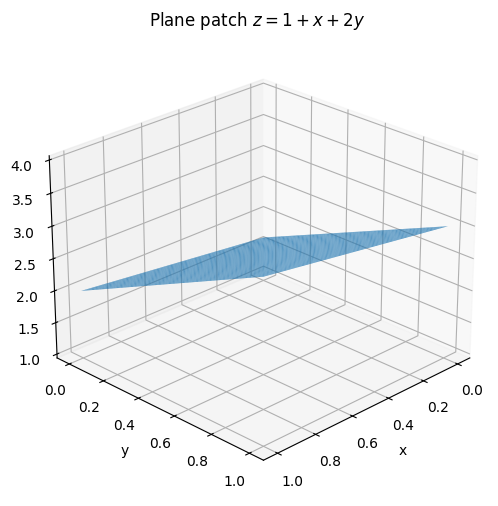

Plane patch surface area: 2.4494897427831783
Exact area: 2.449489742783178


In [9]:
def plane_param(U, V):
    return U, V, 1 + U + 2*V

def plane_ru(U, V):
    return np.ones_like(U), 0*U, np.ones_like(U)

def plane_rv(U, V):
    return 0*V, np.ones_like(V), 2*np.ones_like(V)

plot_param_surface(
    plane_param,
    0, 1, 0, 1,
    title=r"Plane patch $z=1+x+2y$"
)

area_plane, *_ = param_surface_integral_scalar(
    plane_param,
    plane_ru,
    plane_rv,
    one3,
    0, 1, 0, 1,
    nu=200,
    nv=200
)

print("Plane patch surface area:", area_plane)
print("Exact area:", np.sqrt(6))

## 8. Tangent vectors and normal vector at one point

In [10]:
U0, V0 = 0.5, 0.5
p = np.array(plane_param(U0, V0), dtype=float)
ru_vec = np.array(plane_ru(U0, V0), dtype=float)
rv_vec = np.array(plane_rv(U0, V0), dtype=float)
normal_vec = np.cross(ru_vec, rv_vec)

print("point r(u,v):", p)
print("r_u:", ru_vec)
print("r_v:", rv_vec)
print("r_u x r_v:", normal_vec)
print("area scaling:", norm(normal_vec))
print("dot with r_u:", normal_vec @ ru_vec)
print("dot with r_v:", normal_vec @ rv_vec)

point r(u,v): [0.5 0.5 2.5]
r_u: [1. 0. 1.]
r_v: [0. 1. 2.]
r_u x r_v: [-1. -2.  1.]
area scaling: 2.449489742783178
dot with r_u: 0.0
dot with r_v: 0.0


---

# Part IV. Scalar surface integrals

A scalar surface integral accumulates a scalar field over a surface:

$$
\iint_S f\,dS.
$$

Using a parametrization,

$$
\iint_S f\,dS
=
\iint_D f(\mathbf r(u,v))|\mathbf r_u\times\mathbf r_v|\,du\,dv.
$$

## 9. Scalar surface integral over a plane patch

Compute

$$
\iint_S z\,dS
$$

over the plane patch

$$
z=1+x+2y,\qquad 0\leq x,y\leq1.
$$

Since $dS=\sqrt6\,dx\,dy$, this is

$$
\sqrt6\int_0^1\int_0^1(1+x+2y)\,dy\,dx.
$$

In [11]:
def scalar_z(X, Y, Z):
    return Z

int_z_plane, *_ = param_surface_integral_scalar(
    plane_param,
    plane_ru,
    plane_rv,
    scalar_z,
    0, 1, 0, 1,
    nu=300,
    nv=300
)

# average of z over the unit square is 1 + 1/2 + 2*(1/2)=2.5
exact_int_z_plane = 2.5*np.sqrt(6)

print("Scalar surface integral estimate:", int_z_plane)
print("Exact value:", exact_int_z_plane)

Scalar surface integral estimate: 6.123724356957945
Exact value: 6.123724356957945


## 10. Surface area of a graph

If

$$
S:\quad z=g(x,y),
$$

then

$$
dS=\sqrt{1+g_x^2+g_y^2}\,dx\,dy.
$$

For

$$
g(x,y)=x^2+y^2
$$

over $[-1,1]\times[-1,1]$,

$$
dS=\sqrt{1+4x^2+4y^2}\,dx\,dy.
$$

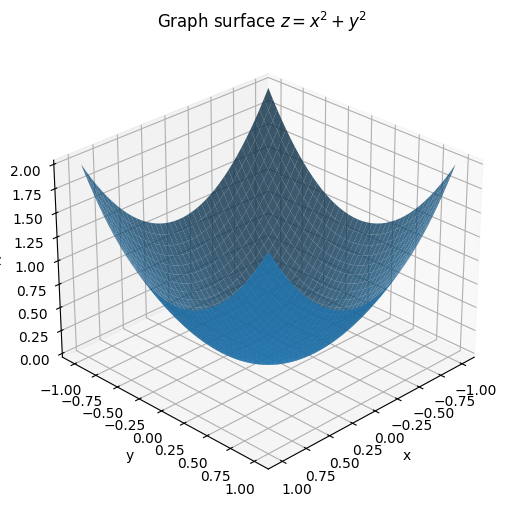

Surface area estimate for z=x^2+y^2 over [-1,1]^2: 7.446248139339907


In [12]:
def g_paraboloid(X, Y):
    return X**2 + Y**2

def gx_paraboloid(X, Y):
    return 2*X

def gy_paraboloid(X, Y):
    return 2*Y

plot_graph_surface(
    g_paraboloid,
    -1, 1,
    -1, 1,
    title=r"Graph surface $z=x^2+y^2$"
)

area_graph, *_ = graph_surface_area(
    gx_paraboloid,
    gy_paraboloid,
    -1, 1,
    -1, 1,
    nx=500,
    ny=500
)

print("Surface area estimate for z=x^2+y^2 over [-1,1]^2:", area_graph)

---

# Part V. Flux through oriented surfaces

For an oriented surface, the flux of $\mathbf F$ through $S$ is

$$
\iint_S\mathbf F\cdot\mathbf n\,dS.
$$

With a parametrization whose orientation is given by $\mathbf r_u\times\mathbf r_v$,

$$
\iint_S \mathbf F\cdot\mathbf n\,dS
=
\iint_D \mathbf F(\mathbf r(u,v))\cdot
(\mathbf r_u\times\mathbf r_v)\,du\,dv.
$$

Orientation matters: reversing the normal changes the sign.

## 11. Flux through a horizontal square

Let

$$
S:\quad 0\leq x\leq1,\quad 0\leq y\leq1,\quad z=2,
$$

oriented upward.

Let

$$
\mathbf F(x,y,z)=\langle x,y,z\rangle.
$$

On the surface, the upward normal is $\mathbf k$, so

$$
\mathbf F\cdot\mathbf n=z=2.
$$

The flux is $2$.

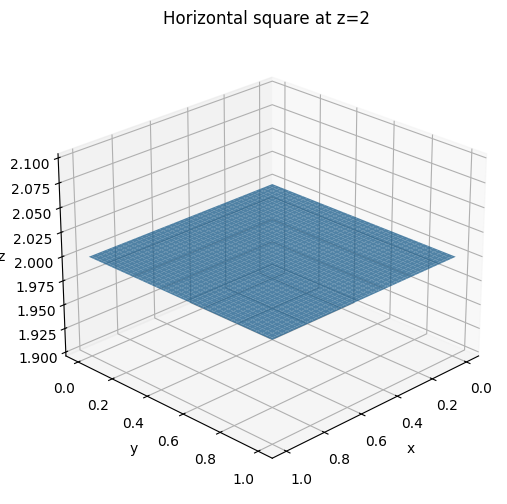

Upward flux through square: 2.0
Exact value: 2.0


In [13]:
def square_param(U, V):
    return U, V, 2*np.ones_like(U)

def square_ru(U, V):
    return np.ones_like(U), 0*U, 0*U

def square_rv(U, V):
    return 0*V, np.ones_like(V), 0*V

flux_square, *_ = param_surface_flux(
    F_radial3,
    square_param,
    square_ru,
    square_rv,
    0, 1, 0, 1,
    nu=200,
    nv=200
)

plot_param_surface(
    square_param,
    0, 1, 0, 1,
    title="Horizontal square at z=2"
)

print("Upward flux through square:", flux_square)
print("Exact value:", 2.0)

## 12. Reversing orientation

If we swap the parameter order, the normal changes sign:

$$
\mathbf r_v\times\mathbf r_u=-(\mathbf r_u\times\mathbf r_v).
$$

The flux should become negative.

In [14]:
flux_square_reversed, *_ = param_surface_flux(
    F_radial3,
    square_param,
    square_rv,
    square_ru,
    0, 1, 0, 1,
    nu=200,
    nv=200
)

print("Original upward flux:", flux_square)
print("Reversed orientation flux:", flux_square_reversed)
print("Sum:", flux_square + flux_square_reversed)

Original upward flux: 2.0
Reversed orientation flux: -2.0
Sum: 0.0


## 13. Flux through a graph surface

For a graph $z=g(x,y)$ with upward orientation,

$$
\mathbf n\,dS=\langle -g_x,-g_y,1\rangle\,dx\,dy.
$$

Thus

$$
\iint_S\mathbf F\cdot\mathbf n\,dS
=
\iint_D
\mathbf F(x,y,g(x,y))\cdot
\langle -g_x,-g_y,1\rangle\,dx\,dy.
$$

In [15]:
def F_vertical(X, Y, Z):
    return 0*X, 0*Y, Z

flux_graph, *_ = graph_surface_flux_upward(
    F_vertical,
    g_paraboloid,
    gx_paraboloid,
    gy_paraboloid,
    -1, 1,
    -1, 1,
    nx=500,
    ny=500
)

# Since F=<0,0,z>, upward flux integrand is z=x^2+y^2.
# Integral over [-1,1]^2: ∫∫(x^2+y^2)= 8/3.
exact_flux_graph = 8/3

print("Flux through paraboloid graph:", flux_graph)
print("Exact value:", exact_flux_graph)

Flux through paraboloid graph: 2.666656
Exact value: 2.6666666666666665


---

# Part VI. Cylinders and spheres

Cylinders and spheres are standard surfaces in vector calculus.

A cylinder of radius $R$ may be parametrized by

$$
\mathbf r(\theta,z)=\langle R\cos\theta,R\sin\theta,z\rangle.
$$

A sphere of radius $R$ may be parametrized by

$$
\mathbf r(\phi,\theta)=
\langle R\sin\phi\cos\theta,\;R\sin\phi\sin\theta,\;R\cos\phi\rangle.
$$

## 14. Flux through a cylinder side

For the side of a cylinder

$$
x^2+y^2=R^2,\qquad 0\leq z\leq h,
$$

oriented outward, use

$$
\mathbf r(\theta,z)=\langle R\cos\theta,R\sin\theta,z\rangle.
$$

With parameters $(\theta,z)$,

$$
\mathbf r_\theta\times \mathbf r_z
=
\langle R\cos\theta,R\sin\theta,0\rangle,
$$

which points outward.

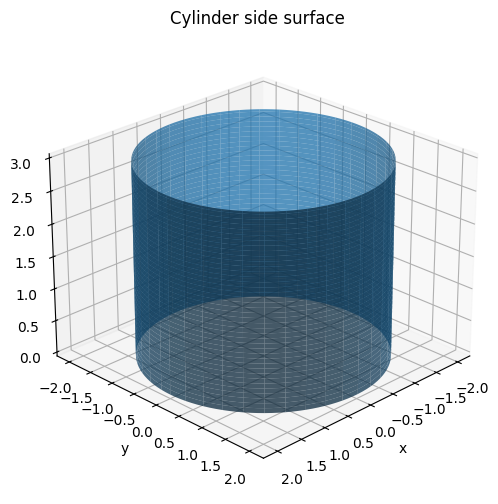

Flux through cylinder side: 75.39822368615502
Exact value: 75.39822368615503


In [16]:
R = 2.0
h = 3.0

def cyl_param(Theta, Z):
    return R*np.cos(Theta), R*np.sin(Theta), Z

def cyl_rtheta(Theta, Z):
    return -R*np.sin(Theta), R*np.cos(Theta), 0*Theta

def cyl_rz(Theta, Z):
    return 0*Z, 0*Z, np.ones_like(Z)

plot_param_surface(
    cyl_param,
    0, 2*np.pi,
    0, h,
    nu=120,
    nv=80,
    title="Cylinder side surface"
)

flux_cylinder_side, *_ = param_surface_flux(
    F_radial3,
    cyl_param,
    cyl_rtheta,
    cyl_rz,
    0, 2*np.pi,
    0, h,
    nu=300,
    nv=160
)

# On side, F=<x,y,z>, outward n dS=<x,y,0> dtheta dz.
# Dot = x^2+y^2=R^2. Integral = R^2*(2π)*h.
exact_flux_cylinder_side = R**2*2*np.pi*h

print("Flux through cylinder side:", flux_cylinder_side)
print("Exact value:", exact_flux_cylinder_side)

## 15. Flux through a sphere

For the sphere of radius $R$ oriented outward,

$$
\mathbf F=\langle x,y,z\rangle
$$

satisfies

$$
\mathbf F\cdot\mathbf n=R,
$$

and

$$
dS=R^2\sin\phi\,d\phi\,d\theta.
$$

So the outward flux is

$$
4\pi R^3.
$$

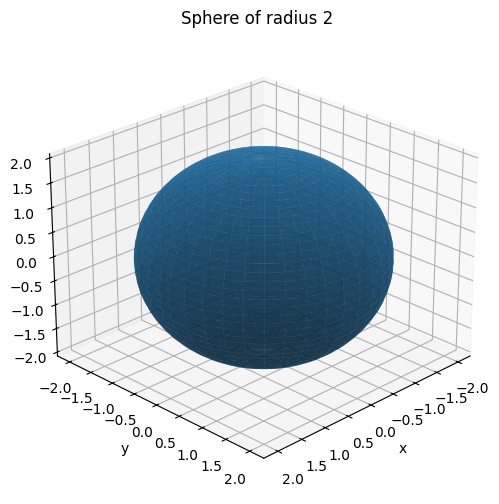

Flux through sphere: -100.53168265634649
Exact value: 100.53096491487338
Error: -201.06264757121988


In [17]:
Rs = 2.0

def sphere_param(Phi, Theta):
    return (
        Rs*np.sin(Phi)*np.cos(Theta),
        Rs*np.sin(Phi)*np.sin(Theta),
        Rs*np.cos(Phi)
    )

def sphere_rphi(Phi, Theta):
    return (
        Rs*np.cos(Phi)*np.cos(Theta),
        Rs*np.cos(Phi)*np.sin(Theta),
        -Rs*np.sin(Phi)
    )

def sphere_rtheta(Phi, Theta):
    return (
        -Rs*np.sin(Phi)*np.sin(Theta),
        Rs*np.sin(Phi)*np.cos(Theta),
        0*Theta
    )

# r_theta x r_phi is outward for this convention.
def sphere_rtheta_for_out(Phi, Theta):
    return sphere_rtheta(Phi, Theta)

def sphere_rphi_for_out(Phi, Theta):
    return sphere_rphi(Phi, Theta)

plot_param_surface(
    sphere_param,
    0, np.pi,
    0, 2*np.pi,
    nu=80,
    nv=120,
    title="Sphere of radius 2"
)

flux_sphere, *_ = param_surface_flux(
    F_radial3,
    sphere_param,
    sphere_rtheta_for_out,
    sphere_rphi_for_out,
    0, np.pi,
    0, 2*np.pi,
    nu=240,
    nv=300
)

exact_flux_sphere = 4*np.pi*Rs**3

print("Flux through sphere:", flux_sphere)
print("Exact value:", exact_flux_sphere)
print("Error:", flux_sphere - exact_flux_sphere)

### Note on orientation

For the sphere parametrization $\mathbf r(\phi,\theta)$, the cross product

$$
\mathbf r_\phi\times\mathbf r_\theta
$$

points inward.  
The outward normal is obtained by

$$
\mathbf r_\theta\times\mathbf r_\phi.
$$

This is why the order was chosen carefully in the code.

---

# Part VII. Divergence theorem checks

The divergence theorem says that for a closed oriented surface $S=\partial E$,

$$
\iint_S \mathbf F\cdot\mathbf n\,dS
=
\iiint_E \nabla\cdot\mathbf F\,dV.
$$

This chapter focuses on curl, divergence, and surface integrals; this theorem gives a useful numerical consistency check.

## 16. Sphere check for $\mathbf F=\langle x,y,z\rangle$

Since

$$
\nabla\cdot\mathbf F=3,
$$

the volume integral over a ball of radius $R$ is

$$
3\cdot\frac{4}{3}\pi R^3=4\pi R^3.
$$

This matches the flux through the sphere.

In [18]:
divergence_volume_sphere = 3*(4*np.pi*Rs**3/3)

print("Surface flux through sphere:", flux_sphere)
print("Volume integral of divergence:", divergence_volume_sphere)

Surface flux through sphere: -100.53168265634649
Volume integral of divergence: 100.53096491487338


## 17. Closed cylinder check

For the closed cylinder of radius $R=2$ and height $h=3$:

- side flux: $2\pi R^2h$;
- top flux: $z=h$ over area $\pi R^2$, so top flux is $h\pi R^2$;
- bottom flux: outward normal is downward and $z=0$, so bottom flux is $0$.

Total flux should be

$$
3\cdot \pi R^2h.
$$

In [19]:
# Top disk parameterized upward at z=h.
def top_disk_param(r, theta):
    return r*np.cos(theta), r*np.sin(theta), h*np.ones_like(r)

def top_disk_rr(r, theta):
    return np.cos(theta), np.sin(theta), 0*r

def top_disk_rtheta(r, theta):
    return -r*np.sin(theta), r*np.cos(theta), 0*r

flux_top, *_ = param_surface_flux(
    F_radial3,
    top_disk_param,
    top_disk_rr,
    top_disk_rtheta,
    0, R,
    0, 2*np.pi,
    nu=220,
    nv=300
)

# Bottom disk outward normal is downward.
def bottom_disk_param(r, theta):
    return r*np.cos(theta), r*np.sin(theta), 0*r

# r_theta x r gives downward orientation.
flux_bottom, *_ = param_surface_flux(
    F_radial3,
    bottom_disk_param,
    top_disk_rtheta,
    top_disk_rr,
    0, R,
    0, 2*np.pi,
    nu=220,
    nv=300
)

total_closed_cylinder_flux = flux_cylinder_side + flux_top + flux_bottom
divergence_volume_cylinder = 3*np.pi*R**2*h

print("Side flux:", flux_cylinder_side)
print("Top flux:", flux_top)
print("Bottom flux:", flux_bottom)
print("Total closed-cylinder flux:", total_closed_cylinder_flux)
print("Volume integral of divergence:", divergence_volume_cylinder)

Side flux: 75.39822368615502
Top flux: 37.69911184307752
Bottom flux: 0.0
Total closed-cylinder flux: 113.09733552923254
Volume integral of divergence: 113.09733552923255


---

# Part VIII. Curl and circulation checks

Stokes' theorem says that circulation around a boundary curve is related to the surface integral of curl:

$$
\oint_{\partial S}\mathbf F\cdot d\mathbf r
=
\iint_S(\nabla\times\mathbf F)\cdot\mathbf n\,dS.
$$

This chapter prepares the objects needed for this theorem: curl and oriented surface integrals.

We now check a simple flat-surface example.

## 18. Disk bounded by a circle

Let

$$
\mathbf F=\langle -y,x,0\rangle.
$$

Then

$$
\nabla\times\mathbf F=\langle0,0,2\rangle.
$$

For the unit disk in the $xy$-plane oriented upward,

$$
\iint_S(\nabla\times\mathbf F)\cdot\mathbf k\,dS
=
\iint_D2\,dA=2\pi.
$$

The boundary circulation should also be $2\pi$.

In [20]:
def F_rotation_z_2d_path(t):
    return np.cos(t), np.sin(t), 0*t

def line_integral_3d(F, r, rp, a, b, n=4000):
    t = np.linspace(a, b, n)
    X, Y, Z = r(t)
    dX, dY, dZ = rp(t)
    P, Q, Rcomp = F(X, Y, Z)
    integrand = P*dX + Q*dY + Rcomp*dZ
    return float(np.trapezoid(integrand, t)), t, integrand

def r_unit_circle_3d(t):
    return np.cos(t), np.sin(t), 0*t

def rp_unit_circle_3d(t):
    return -np.sin(t), np.cos(t), 0*t

circ, *_ = line_integral_3d(F_rotation_z, r_unit_circle_3d, rp_unit_circle_3d, 0, 2*np.pi)

# Curl surface integral over unit disk upward.
def curl_z_constant(X, Y, Z):
    return 0*X, 0*Y, 2*np.ones_like(X)

curl_flux_disk, *_ = graph_surface_flux_upward(
    curl_z_constant,
    lambda X, Y: 0*X,
    lambda X, Y: 0*X,
    lambda X, Y: 0*Y,
    -1, 1,
    -1, 1,
    nx=500,
    ny=500
)

# The graph integral above is over the square; we need mask for disk.
def disk_integrand(X, Y):
    return 2*np.ones_like(X)

disk_val, *_ = midpoint_rectangle_2d(
    lambda X, Y: np.where(X**2+Y**2 <= 1, 2.0, 0.0),
    -1, 1, -1, 1,
    nu=700,
    nv=700
)

print("Boundary circulation:", circ)
print("Curl flux over disk:", disk_val)
print("Exact value:", 2*np.pi)

Boundary circulation: 6.283185307179586
Curl flux over disk: 6.283297959183674
Exact value: 6.283185307179586


---

# Part IX. More graph-surface flux examples

Graph surfaces are common in applications: terrain, membranes, sensors, solar panels, and material interfaces.

For upward orientation,

$$
\mathbf n\,dS=\langle -g_x,-g_y,1\rangle\,dx\,dy.
$$

## 19. Flux through a tilted plane in a vertical field

Let

$$
S:\quad z=1+x+2y
$$

over $[0,1]\times[0,1]$, oriented upward.

Let

$$
\mathbf F=\langle 0,0,1\rangle.
$$

Then the upward flux is simply the area of the projection, which is $1$:

$$
\mathbf F\cdot\langle -g_x,-g_y,1\rangle=1.
$$

In [21]:
def g_plane(X, Y):
    return 1 + X + 2*Y

def gx_plane(X, Y):
    return np.ones_like(X)

def gy_plane(X, Y):
    return 2*np.ones_like(Y)

def F_vertical_unit(X, Y, Z):
    return 0*X, 0*Y, np.ones_like(Z)

flux_tilted_plane, *_ = graph_surface_flux_upward(
    F_vertical_unit,
    g_plane,
    gx_plane,
    gy_plane,
    0, 1,
    0, 1,
    nx=300,
    ny=300
)

print("Upward flux of vertical unit field through tilted plane:", flux_tilted_plane)
print("Exact value:", 1.0)

Upward flux of vertical unit field through tilted plane: 1.0
Exact value: 1.0


## 20. Flux through a paraboloid in a nonvertical field

Let

$$
S:\quad z=x^2+y^2
$$

over $[-1,1]^2$, oriented upward.

Let

$$
\mathbf F=\langle x,y,z\rangle.
$$

Then the flux integrand is

$$
\langle x,y,x^2+y^2\rangle\cdot\langle -2x,-2y,1\rangle
=
-x^2-y^2.
$$

In [22]:
flux_paraboloid_radial, *_ = graph_surface_flux_upward(
    F_radial3,
    g_paraboloid,
    gx_paraboloid,
    gy_paraboloid,
    -1, 1,
    -1, 1,
    nx=500,
    ny=500
)

exact_flux_paraboloid_radial = -8/3

print("Flux estimate:", flux_paraboloid_radial)
print("Exact value:", exact_flux_paraboloid_radial)

Flux estimate: -2.666656
Exact value: -2.6666666666666665


### Guided task 2

Change the orientation of the paraboloid surface from upward to downward.  
What should happen to the flux?

In [23]:
print("Upward flux:", flux_paraboloid_radial)
print("Downward flux should be:", -flux_paraboloid_radial)

Upward flux: -2.666656
Downward flux should be: 2.666656


---

# Part X. Surface area and flux from sampled parameter grids

In applications, surfaces may be represented by sampled grids rather than exact formulas.

A common approximation is to split each small parameter rectangle into two triangles and add triangle areas or flux contributions.

## 21. Triangle mesh approximation of a graph surface

We approximate the surface area of

$$
z=x^2+y^2
$$

over $[-1,1]^2$ using triangular mesh cells.

In [24]:
def triangle_area_3d(A, B, C):
    return 0.5*norm(np.cross(B-A, C-A), axis=-1)

def mesh_area_graph(g, xmin, xmax, ymin, ymax, nx=80, ny=80):
    x = np.linspace(xmin, xmax, nx+1)
    y = np.linspace(ymin, ymax, ny+1)
    X, Y = np.meshgrid(x, y, indexing="ij")
    Z = g(X, Y)
    P = np.stack([X, Y, Z], axis=-1)
    A = P[:-1, :-1]
    B = P[1:, :-1]
    C = P[1:, 1:]
    D = P[:-1, 1:]
    area1 = triangle_area_3d(A, B, C)
    area2 = triangle_area_3d(A, C, D)
    return float(np.sum(area1 + area2))

for n in [20, 40, 80, 160]:
    mesh_area = mesh_area_graph(g_paraboloid, -1, 1, -1, 1, nx=n, ny=n)
    print(f"n={n:4d}, mesh area={mesh_area:.8f}, difference from midpoint area={mesh_area-area_graph:.8f}")

n=  20, mesh area=7.44089053, difference from midpoint area=-0.00535761
n=  40, mesh area=7.44491544, difference from midpoint area=-0.00133270
n=  80, mesh area=7.44592142, difference from midpoint area=-0.00032672
n= 160, mesh area=7.44617290, difference from midpoint area=-0.00007524


---

# Part XI. Chapter mini-project: flux through a curved sensor surface

A curved sensor is modeled as the graph

$$
z=g(x,y)=0.4e^{-x^2-y^2}+0.15\sin(2x)\cos(2y)
$$

over the square

$$
-1.5\leq x\leq1.5,\qquad -1.5\leq y\leq1.5.
$$

A vector field represents particle flow:

$$
\mathbf F(x,y,z)=
\langle
0.3x-y,\;
x+0.2y,\;
1+0.5z
\rangle.
$$

You will compute:

1. the surface area of the sensor;
2. the upward flux through the sensor;
3. the downward flux;
4. the average normal flux per unit surface area;
5. a visualization of local flux density.

## 22. Define the sensor and flow field

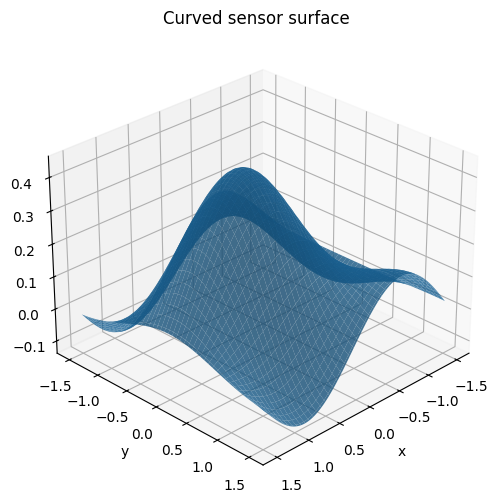

Sensor surface area: 9.43003945950653
Upward flux through sensor: 10.064604992449254
Downward flux through sensor: -10.064604992449254
Average upward flux per unit surface area: 1.067291927639074


In [25]:
def g_sensor(X, Y):
    return 0.4*np.exp(-X**2-Y**2) + 0.15*np.sin(2*X)*np.cos(2*Y)

def gx_sensor(X, Y):
    return -0.8*X*np.exp(-X**2-Y**2) + 0.3*np.cos(2*X)*np.cos(2*Y)

def gy_sensor(X, Y):
    return -0.8*Y*np.exp(-X**2-Y**2) - 0.3*np.sin(2*X)*np.sin(2*Y)

def F_flow(X, Y, Z):
    return 0.3*X - Y, X + 0.2*Y, 1 + 0.5*Z

plot_graph_surface(
    g_sensor,
    -1.5, 1.5,
    -1.5, 1.5,
    n=140,
    title="Curved sensor surface"
)

area_sensor, U, V, area_density = graph_surface_area(
    gx_sensor,
    gy_sensor,
    -1.5, 1.5,
    -1.5, 1.5,
    nx=600,
    ny=600
)

flux_sensor, Xmid, Ymid, flux_density = graph_surface_flux_upward(
    F_flow,
    g_sensor,
    gx_sensor,
    gy_sensor,
    -1.5, 1.5,
    -1.5, 1.5,
    nx=600,
    ny=600
)

print("Sensor surface area:", area_sensor)
print("Upward flux through sensor:", flux_sensor)
print("Downward flux through sensor:", -flux_sensor)
print("Average upward flux per unit surface area:", flux_sensor/area_sensor)

## 23. Visualize local flux density

The upward oriented flux density over the parameter domain is

$$
\mathbf F(x,y,g(x,y))\cdot\langle -g_x,-g_y,1\rangle.
$$

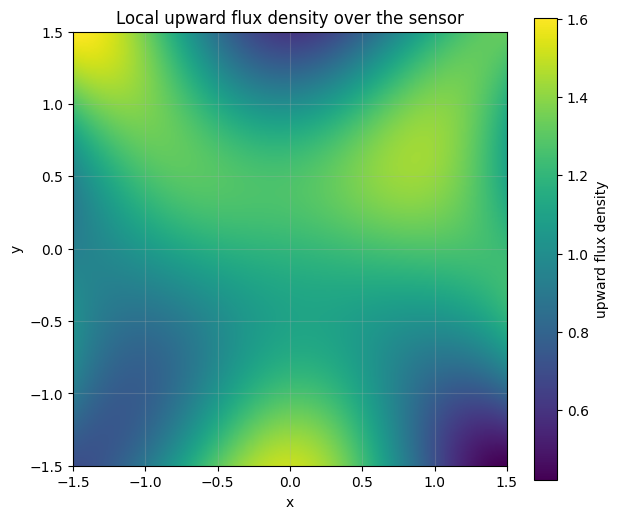

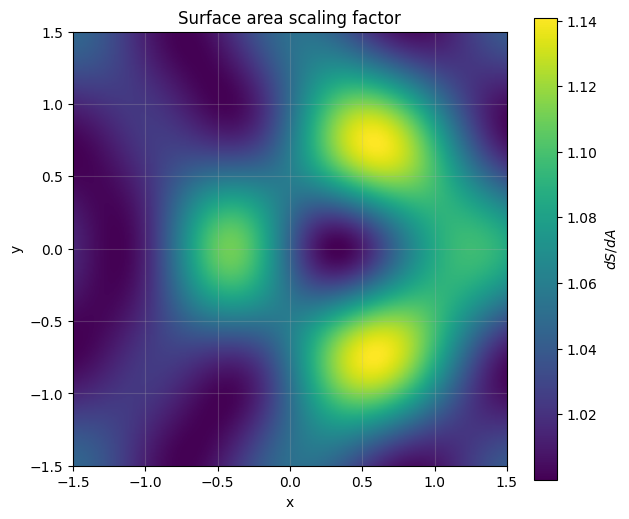

In [26]:
x, y, X, Y = make_grid2d(-1.5, 1.5, -1.5, 1.5, n=350)
Z = g_sensor(X, Y)
P, Q, Rcomp = F_flow(X, Y, Z)
local_flux = P*(-gx_sensor(X, Y)) + Q*(-gy_sensor(X, Y)) + Rcomp

plt.figure(figsize=(7, 6))
im = plt.imshow(local_flux, extent=[-1.5,1.5,-1.5,1.5], origin="lower", aspect="equal")
plt.colorbar(im, label="upward flux density")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Local upward flux density over the sensor")
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(7, 6))
im = plt.imshow(np.sqrt(1 + gx_sensor(X,Y)**2 + gy_sensor(X,Y)**2),
                extent=[-1.5,1.5,-1.5,1.5], origin="lower", aspect="equal")
plt.colorbar(im, label=r"$dS/dA$")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Surface area scaling factor")
plt.grid(True, alpha=0.25)
plt.show()

## 24. Compare with the flat projection

If the sensor were flat at $z=0$, upward flux through the square would be

$$
\int_{-1.5}^{1.5}\int_{-1.5}^{1.5}1\,dx\,dy=9.
$$

The curved surface changes both the height $z$ and the normal direction.

In [27]:
flat_flux = 9.0
print("Flat projection flux for F_z=1:", flat_flux)
print("Curved sensor upward flux:", flux_sensor)
print("Difference:", flux_sensor - flat_flux)

Flat projection flux for F_z=1: 9.0
Curved sensor upward flux: 10.064604992449254
Difference: 1.0646049924492544


## 25. Mini-project questions

Answer the following in a markdown cell:

1. Why is the upward normal area vector $\langle -g_x,-g_y,1\rangle\,dx\,dy$?
2. Where is the local flux density largest?
3. Where is it smallest?
4. Why can the total flux be different from the flat projected flux?
5. What does the average flux per unit surface area measure physically?
6. How would the sign change if the sensor were oriented downward?

In [28]:
print("Sensor mini-project summary")
print("---------------------------")
print("Surface area:", area_sensor)
print("Upward flux:", flux_sensor)
print("Downward flux:", -flux_sensor)
print("Average upward flux per unit surface area:", flux_sensor/area_sensor)
print("Maximum local flux density:", np.nanmax(local_flux))
print("Minimum local flux density:", np.nanmin(local_flux))

Sensor mini-project summary
---------------------------
Surface area: 9.43003945950653
Upward flux: 10.064604992449254
Downward flux: -10.064604992449254
Average upward flux per unit surface area: 1.067291927639074
Maximum local flux density: 1.603287215957247
Minimum local flux density: 0.42122265776144063


---

# Part XII. Additional exercises with reference solutions

Try each exercise before running the reference solution.

## Exercise A. Divergence and curl

For

$$
\mathbf F(x,y,z)=\langle x^2,y^2,z^2\rangle,
$$

compute divergence and curl at $(1,2,3)$.

In [29]:
# Exercise A workspace

# Your code here

### Reference solution for Exercise A

In [30]:
def F_A(X, Y, Z):
    return X**2, Y**2, Z**2

p = (1.0, 2.0, 3.0)
div_A = numerical_divergence_3d(F_A, *p)
curl_A = numerical_curl_3d(F_A, *p)

print("Numerical divergence:", div_A)
print("Exact divergence:", 2*p[0] + 2*p[1] + 2*p[2])
print("Numerical curl:", np.array(curl_A))
print("Exact curl:", np.array([0,0,0]))

Numerical divergence: 12.000000000067512
Exact divergence: 12.0
Numerical curl: [0. 0. 0.]
Exact curl: [0 0 0]


## Exercise B. Plane surface area

Compute the surface area of

$$
z=2x-y
$$

over

$$
0\leq x\leq2,\qquad 0\leq y\leq1.
$$

In [31]:
# Exercise B workspace

# Your code here

### Reference solution for Exercise B

In [32]:
def gx_B(X, Y):
    return 2*np.ones_like(X)

def gy_B(X, Y):
    return -np.ones_like(Y)

area_B, *_ = graph_surface_area(gx_B, gy_B, 0, 2, 0, 1, nx=300, ny=300)
print("Surface area estimate:", area_B)
print("Exact area:", 2*np.sqrt(1+2**2+(-1)**2))

Surface area estimate: 4.898979485566357
Exact area: 4.898979485566356


## Exercise C. Flux through a horizontal disk

Compute the upward flux of

$$
\mathbf F(x,y,z)=\langle x,y,z\rangle
$$

through the disk

$$
x^2+y^2\leq4,\qquad z=3.
$$

In [33]:
# Exercise C workspace

# Your code here

### Reference solution for Exercise C

In [34]:
def disk3_param(r, theta):
    return r*np.cos(theta), r*np.sin(theta), 3*np.ones_like(r)

def disk3_rr(r, theta):
    return np.cos(theta), np.sin(theta), 0*r

def disk3_rtheta(r, theta):
    return -r*np.sin(theta), r*np.cos(theta), 0*r

flux_C, *_ = param_surface_flux(F_radial3, disk3_param, disk3_rr, disk3_rtheta, 0, 2, 0, 2*np.pi, nu=260, nv=360)

print("Flux estimate:", flux_C)
print("Exact value:", 3*np.pi*2**2)

Flux estimate: 37.69911184307752
Exact value: 37.69911184307752


## Exercise D. Sphere flux

Compute the outward flux of

$$
\mathbf F(x,y,z)=\langle 2x,2y,2z\rangle
$$

through the sphere of radius $1$.

In [35]:
# Exercise D workspace

# Your code here

### Reference solution for Exercise D

In [36]:
def F_D(X, Y, Z):
    return 2*X, 2*Y, 2*Z

Rold = Rs
Rs = 1.0

def sphere_param_D(Phi, Theta):
    return (
        Rs*np.sin(Phi)*np.cos(Theta),
        Rs*np.sin(Phi)*np.sin(Theta),
        Rs*np.cos(Phi)
    )

def sphere_rphi_D(Phi, Theta):
    return (
        Rs*np.cos(Phi)*np.cos(Theta),
        Rs*np.cos(Phi)*np.sin(Theta),
        -Rs*np.sin(Phi)
    )

def sphere_rtheta_D(Phi, Theta):
    return (
        -Rs*np.sin(Phi)*np.sin(Theta),
        Rs*np.sin(Phi)*np.cos(Theta),
        0*Theta
    )

flux_D, *_ = param_surface_flux(F_D, sphere_param_D, sphere_rtheta_D, sphere_rphi_D,
                                0, np.pi, 0, 2*np.pi, nu=220, nv=280)

print("Flux estimate:", flux_D)
print("Exact value:", 8*np.pi)

Rs = Rold

Flux estimate: -25.132954771838826
Exact value: 25.132741228718345


## Exercise E. Curl flux through a disk

Let

$$
\mathbf F(x,y,z)=\langle -y,x,0\rangle.
$$

Compute the flux of $\nabla\times\mathbf F$ through the disk $x^2+y^2\leq9$ in the plane $z=0$, oriented upward.

In [37]:
# Exercise E workspace

# Your code here

### Reference solution for Exercise E

In [38]:
# Curl is <0,0,2>. Upward curl flux over radius-3 disk is 2*9π=18π.
disk_curl_flux_E, *_ = midpoint_rectangle_2d(
    lambda X, Y: np.where(X**2+Y**2 <= 9, 2.0, 0.0),
    -3, 3, -3, 3,
    nu=800,
    nv=800
)

print("Curl flux estimate:", disk_curl_flux_E)
print("Exact value:", 18*np.pi)

Curl flux estimate: 56.54835
Exact value: 56.548667764616276


---

# Formula summary

## Divergence

For

$$
\mathbf F=\langle P,Q,R\rangle,
$$

$$
\nabla\cdot\mathbf F=P_x+Q_y+R_z.
$$

## Curl

$$
\nabla\times\mathbf F
=
\left\langle
R_y-Q_z,\;
P_z-R_x,\;
Q_x-P_y
\right\rangle.
$$

## Parametrized surface

$$
\mathbf r(u,v)=\langle x(u,v),y(u,v),z(u,v)\rangle.
$$

## Surface area element

$$
dS=|\mathbf r_u\times\mathbf r_v|\,du\,dv.
$$

## Scalar surface integral

$$
\iint_S f\,dS
=
\iint_D f(\mathbf r(u,v))|\mathbf r_u\times\mathbf r_v|\,du\,dv.
$$

## Flux integral

$$
\iint_S\mathbf F\cdot\mathbf n\,dS
=
\iint_D
\mathbf F(\mathbf r(u,v))\cdot(\mathbf r_u\times\mathbf r_v)\,du\,dv.
$$

## Graph surface

If $z=g(x,y)$ is oriented upward, then

$$
\mathbf n\,dS=\langle -g_x,-g_y,1\rangle\,dx\,dy.
$$

## Divergence theorem check

For a closed surface $S=\partial E$,

$$
\iint_S\mathbf F\cdot\mathbf n\,dS
=
\iiint_E\nabla\cdot\mathbf F\,dV.
$$

## Stokes-type circulation check

For an oriented surface $S$ with boundary $\partial S$,

$$
\oint_{\partial S}\mathbf F\cdot d\mathbf r
=
\iint_S(\nabla\times\mathbf F)\cdot\mathbf n\,dS.
$$

# End of Chapter 22 Lab

You have used Python to explore:

- divergence in three dimensions,
- curl in three dimensions,
- numerical derivative diagnostics,
- vector field slices and 3D arrows,
- parametrized surfaces,
- tangent vectors and normal vectors,
- scalar surface integrals,
- graph surface area,
- flux through oriented surfaces,
- orientation reversal,
- cylinder and sphere flux,
- divergence theorem consistency checks,
- curl and circulation consistency checks,
- mesh-based surface area approximation,
- and a curved-sensor flux mini-project.

These ideas prepare for Stokes' theorem, the divergence theorem, differential forms, electromagnetism, fluid flow, and geometric integration.